# Projet Seaborn: Capteurs IoT (température, humidité, pression, énergie)

**Contexte :** après NumPy, Pandas et Matplotlib, on utilise **Seaborn** pour une analyse exploratoire plus riche : distributions avancées, comparaisons entre groupes, corrélations et relations multivariées.

Structure du projet :
```
Seaborn_Iot_Analysis/
├── data/mesures_capteurs.csv
├── notebooks/Seaborn_Iot_Analysis.ipynb
└── exports/temperature.png, temperature.pdf, ...
```


### Installation, imports et chargement des données

Seaborn s'appuie sur Matplotlib et fonctionne très bien avec des DataFrames Pandas : on lui passe directement le DataFrame et les noms de colonnes, sans extraire les valeurs à la main.

In [4]:
!pip install seaborn matplotlib pandas numpy

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [10]:
sns.set_theme(style="whitegrid")

# Import du dataset
df=pd.read_csv("../data/mesures_capteurs.csv")
df["date_heure"]=pd.to_datetime(df["date_heure"])

#6) Vérification du contenu
print(df.shape)
df.head()

(605, 9)


,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_mesure     605 non-null    object        
 1   date_heure    605 non-null    datetime64[ns]
 2   id_capteur    605 non-null    object        
 3   batiment      605 non-null    object        
 4   temperature   599 non-null    float64       
 5   humidite      600 non-null    float64       
 6   pression      600 non-null    float64       
 7   consommation  600 non-null    float64       
 8   etat          601 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 42.7+ KB


## Partie 1 : Distribution d'une variable avec `histplot()`

`histplot()` affiche un histogramme (comme Matplotlib) mais avec une syntaxe orientée DataFrame et des options avancées (regroupement par catégorie, courbe de densité superposée...).

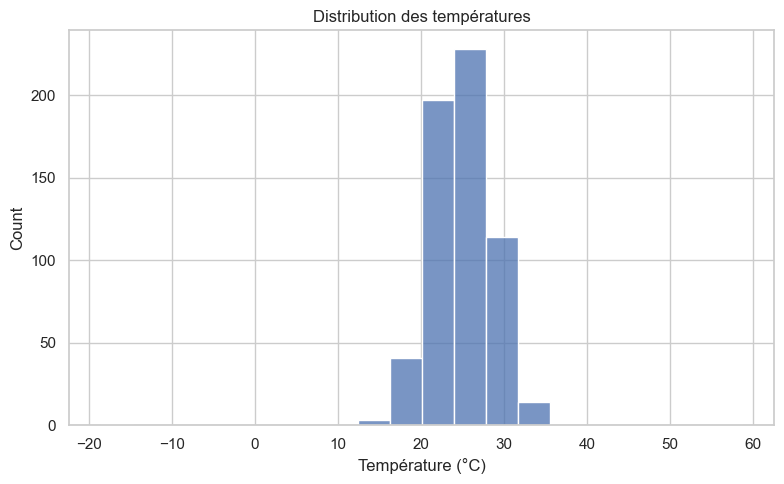

In [12]:
# 1) Distribution des températures
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="temperature", bins=20)
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.tight_layout()
plt.show()

**2) Concentration :** les températures se concentrent autour de la valeur moyenne du jeu de données (proche de 25°C).
**3) Symétrie :** la distribution paraît globalement symétrique, en forme de cloche.
**4) Valeurs extrêmes :** quelques barres isolées, très écartées du groupe principal, suggèrent la présence de valeurs extrêmes.

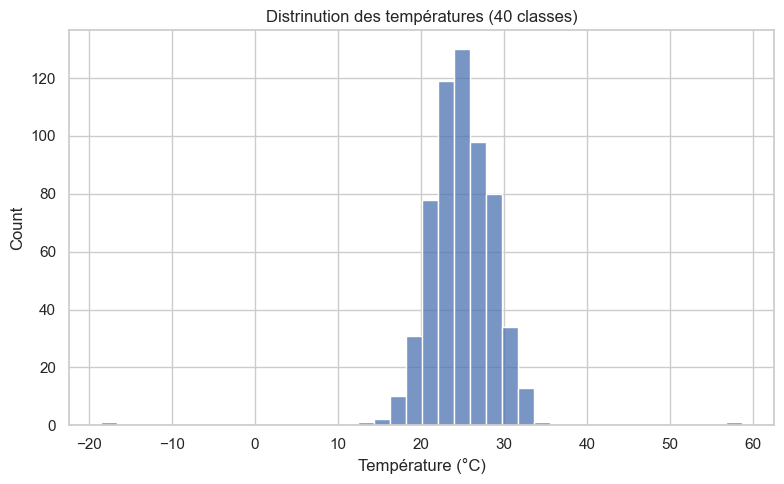

In [13]:
# 5) Modification du nombre de classes
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="temperature", bins=40)
plt.title("Distrinution des températures (40 classes)")
plt.xlabel("Température (°C)")
plt.tight_layout()
plt.show()

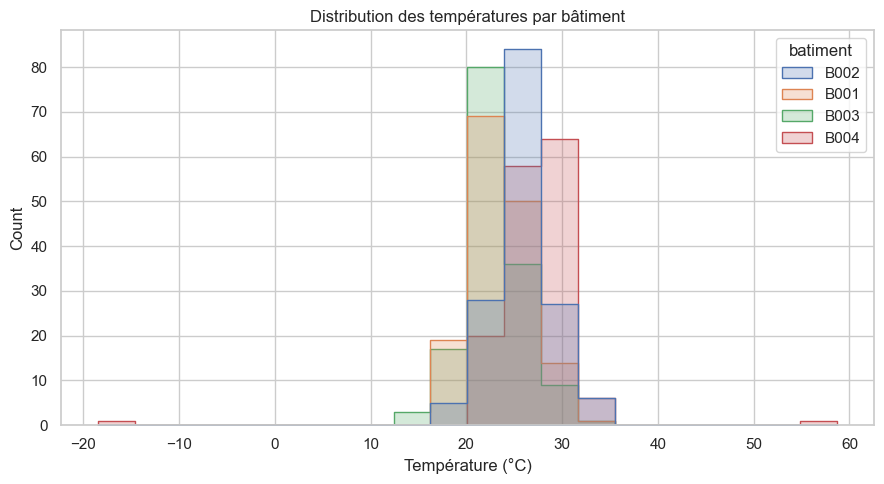

In [14]:
# 6) Distribution des températures par bâtiment
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="temperature", hue="batiment", bins=20, element="step")
plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.tight_layout()
plt.show()


## Partie 2 : Distribution d'une variable avec `kdeplot()`

`kdeplot()` (*Kernel Density Estimate*) trace une **courbe de densité lissée** de la distribution, une alternative continue à l'histogramme.

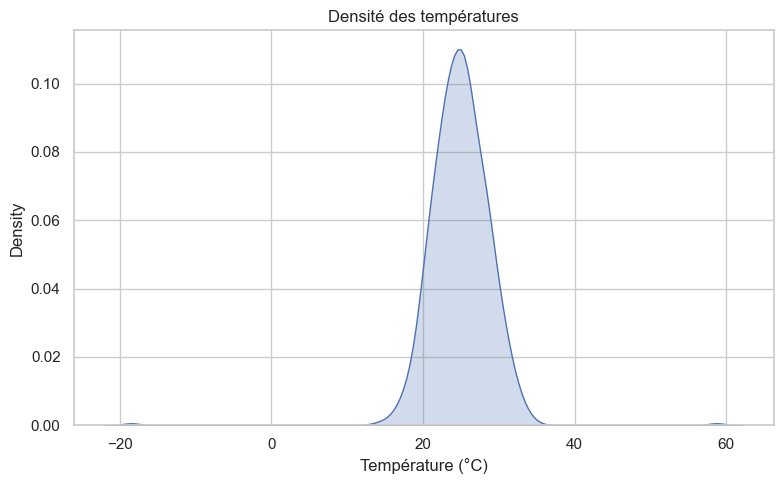

In [15]:
# 1) Distribution des températures (courbe de densité)
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="temperature", fill=True)
plt.title("Densité des températures")
plt.xlabel("Température (°C)")
plt.tight_layout()
plt.show()


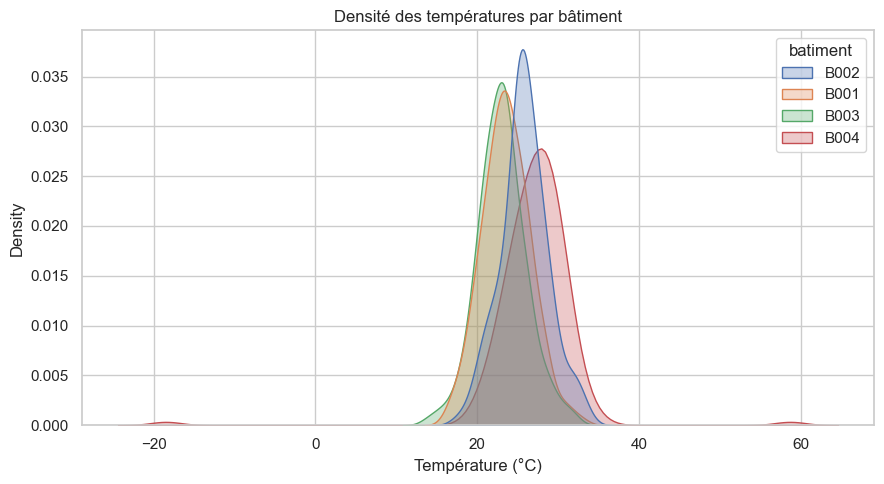

In [16]:
# 2) Distribution des températures par bâtiment
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x="temperature", hue="batiment", fill=True, alpha=0.3)
plt.title("Densité des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.tight_layout()
plt.show()
